In [ ]:
#1: Import and Load Data

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv('../data/raw/heart.csv')
print('Shape:', df.shape)
print('\nColumn types:')
print(df.dtypes)

Shape: (918, 12)

Column types:
Age                 int64
Sex                object
ChestPainType      object
RestingBP           int64
Cholesterol         int64
FastingBS           int64
RestingECG         object
MaxHR               int64
ExerciseAngina     object
Oldpeak           float64
ST_Slope           object
HeartDisease        int64
dtype: object


In [ ]:
#2: Missing values and zero-cholesterol check

print('=== Missing values ===')
print(df.isnull().sum())

print('\n=== Zero values by column ===')
print((df == 0).sum())

print('\n=== Cholesterol zeros ===')
print(f'Zero cholesterol: {(df["Cholesterol"]==0).sum()} out of {len(df)}')
print('This is', round((df["Cholesterol"]==0).mean()*100, 1), '% of records')

=== Missing values ===
Age               0
Sex               0
ChestPainType     0
RestingBP         0
Cholesterol       0
FastingBS         0
RestingECG        0
MaxHR             0
ExerciseAngina    0
Oldpeak           0
ST_Slope          0
HeartDisease      0
dtype: int64

=== Zero values by column ===
Age                 0
Sex                 0
ChestPainType       0
RestingBP           1
Cholesterol       172
FastingBS         704
RestingECG          0
MaxHR               0
ExerciseAngina      0
Oldpeak           368
ST_Slope            0
HeartDisease      410
dtype: int64

=== Cholesterol zeros ===
Zero cholesterol: 172 out of 918
This is 18.7 % of records


=== Target class balance ===
HeartDisease
1    508
0    410
Name: count, dtype: int64
HeartDisease
1    0.553
0    0.447
Name: proportion, dtype: float64


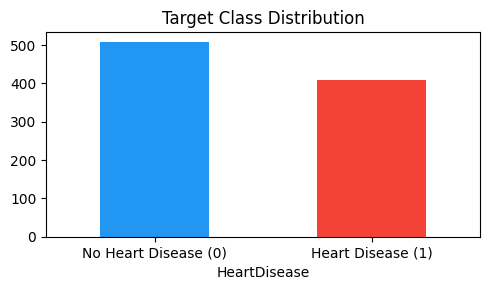

In [ ]:
#3. Class Imbalance

print('=== Target class balance ===')
print(df['HeartDisease'].value_counts())
print(df['HeartDisease'].value_counts(normalize=True).round(3))

fig, ax = plt.subplots(figsize=(5,3))
df['HeartDisease'].value_counts().plot(kind='bar', ax=ax, color=['#2196F3','#F44336'])
ax.set_xticklabels(['No Heart Disease (0)', 'Heart Disease (1)'], rotation=0)
ax.set_title('Target Class Distribution')
plt.tight_layout()
plt.savefig('../docs/class_balance.png', dpi=150)
plt.show()

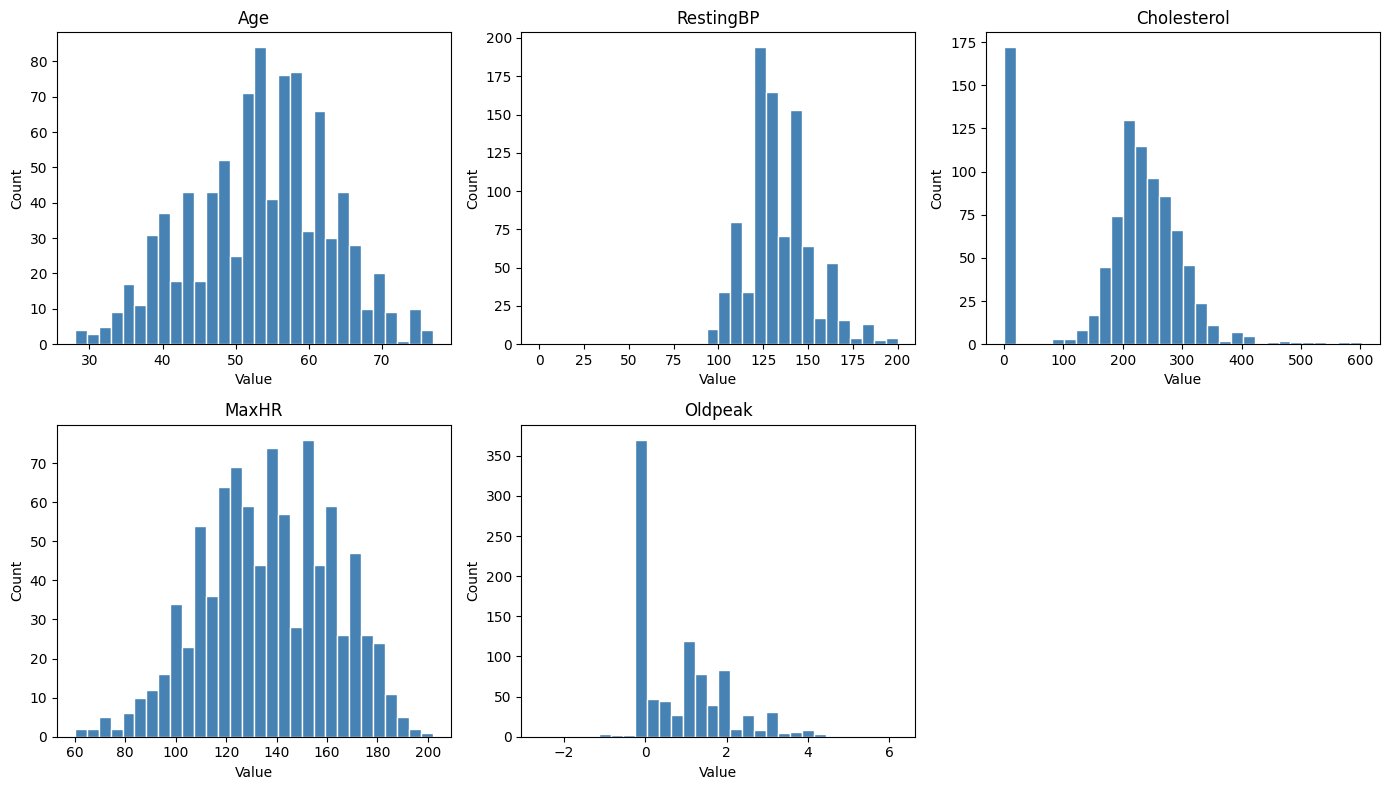

In [4]:
#4. Feature Distribution

num_cols = ['Age', 'RestingBP', 'Cholesterol', 'MaxHR', 'Oldpeak']

fig, axes = plt.subplots(2, 3, figsize=(14, 8))
axes = axes.flatten()

for i, col in enumerate(num_cols):
    axes[i].hist(df[col], bins=30, color='steelblue', edgecolor='white')
    axes[i].set_title(col)
    axes[i].set_xlabel('Value')
    axes[i].set_ylabel('Count')

axes[5].axis('off')
plt.tight_layout()
plt.savefig('../docs/feature_distributions.png', dpi=150)
plt.show()

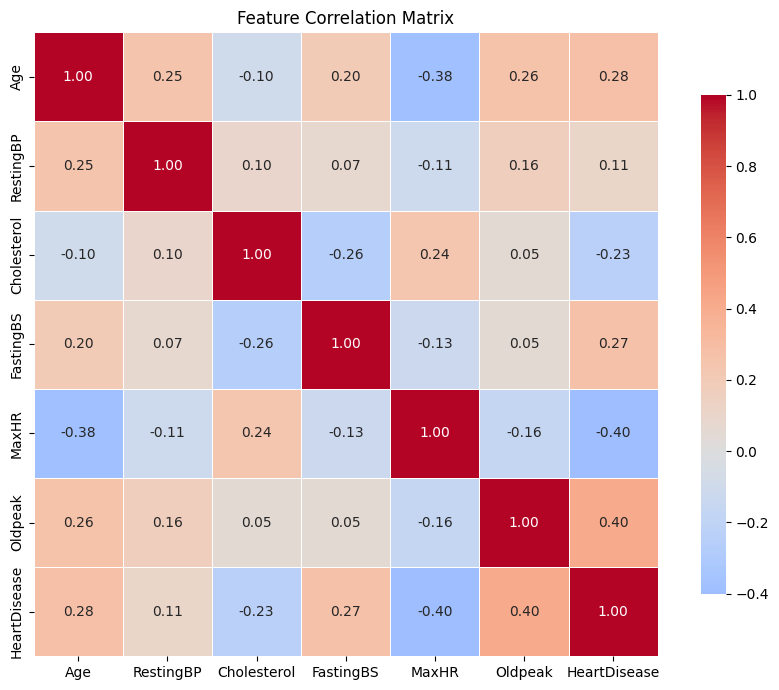


Top correlations with HeartDisease:
HeartDisease    1.000000
Oldpeak         0.403951
Age             0.282039
FastingBS       0.267291
RestingBP       0.107589
Cholesterol    -0.232741
MaxHR          -0.400421
Name: HeartDisease, dtype: float64


In [5]:
#5. Correlation heatmap

fig, ax = plt.subplots(figsize=(9, 7))
corr = df.corr(numeric_only=True)
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm',
            center=0, ax=ax, square=True,
            linewidths=0.5, cbar_kws={'shrink': 0.8})
ax.set_title('Feature Correlation Matrix')
plt.tight_layout()
plt.savefig('../docs/correlation_heatmap.png', dpi=150)
plt.show()

print('\nTop correlations with HeartDisease:')
print(corr['HeartDisease'].sort_values(ascending=False))

=== Descriptive statistics ===
          Age  RestingBP  Cholesterol   MaxHR  Oldpeak
count  918.00     918.00       918.00  918.00   918.00
mean    53.51     132.40       198.80  136.81     0.89
std      9.43      18.51       109.38   25.46     1.07
min     28.00       0.00         0.00   60.00    -2.60
25%     47.00     120.00       173.25  120.00     0.00
50%     54.00     130.00       223.00  138.00     0.60
75%     60.00     140.00       267.00  156.00     1.50
max     77.00     200.00       603.00  202.00     6.20

=== Potential outliers ===
RestingBP > 180: 8 records
Cholesterol > 400: 13 records
MaxHR < 70: 4 records


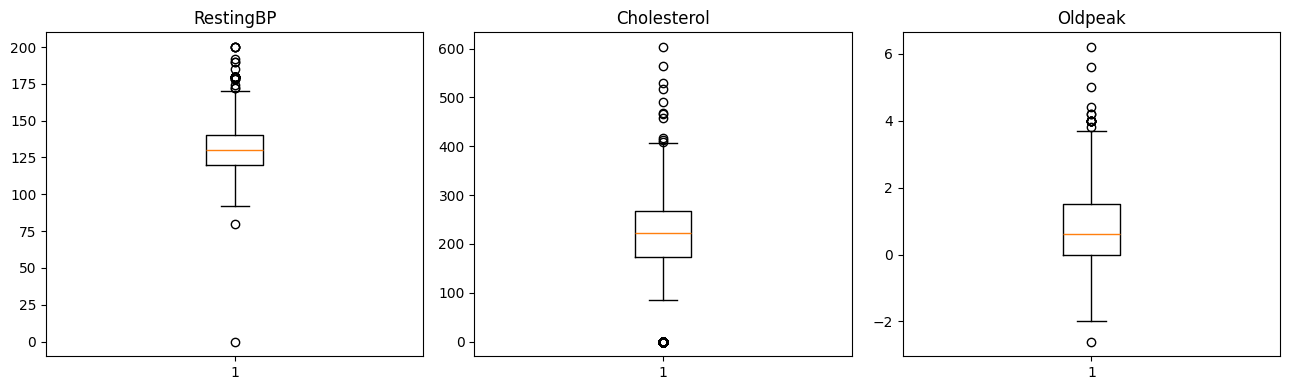

In [6]:
#6. Outlier Analysis

print('=== Descriptive statistics ===')
print(df[num_cols].describe().round(2))

print('\n=== Potential outliers ===')
print(f'RestingBP > 180: {(df["RestingBP"] > 180).sum()} records')
print(f'Cholesterol > 400: {(df["Cholesterol"] > 400).sum()} records')
print(f'MaxHR < 70: {(df["MaxHR"] < 70).sum()} records')

fig, axes = plt.subplots(1, 3, figsize=(13, 4))
for ax, col in zip(axes, ['RestingBP','Cholesterol','Oldpeak']):
    ax.boxplot(df[col])
    ax.set_title(col)
plt.tight_layout()
plt.savefig('../docs/boxplots.png', dpi=150)
plt.show()